# 0. Configure Project Path

In [96]:
import sys
from pathlib import Path

project_root = Path().resolve().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# 1. Import Libraries

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 2. Load Dataset

In [98]:
df = pd.read_csv("../data/raw/projects.csv")

# 3. Descriptive Statistics

In [99]:
df.describe()

,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Past_Similar_Projects,External_Dependencies_Count,Change_Request_Frequency,Team_Turnover_Rate,Vendor_Reliability_Score,...,Market_Volatility,Integration_Complexity,Resource_Availability,Organizational_Change_Frequency,Cross_Functional_Dependencies,Previous_Delivery_Success_Rate,Technical_Debt_Level,Project_Start_Month,Current_Phase_Duration_Months,Seasonal_Risk_Factor
count,4000.000000,4.000000e+03,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000
mean,15.388250,1.143032e+06,17.147750,6.192525,11.130500,1.973750,3.127750,1.638080,0.292725,0.712087,...,0.49716,5.573585,0.651695,1.212215,3.549250,0.750437,0.17544,6.492500,4.074500,1.011325
std,9.220969,5.908781e+05,6.926609,2.212538,4.425875,1.750093,1.609216,1.170451,0.166546,0.163418,...,0.28702,2.606654,0.201163,0.969191,2.320004,0.143712,0.29682,3.476416,2.883926,0.031694
min,2.000000,1.593555e+05,2.000000,1.620000,2.000000,0.000000,0.000000,0.010000,0.000000,0.090000,...,0.00000,1.000000,0.300000,0.000000,0.000000,0.150000,0.00000,1.000000,1.000000,1.000000
25%,9.000000,6.925329e+05,12.000000,4.460000,8.000000,1.000000,2.000000,0.760000,0.160000,0.600000,...,0.25000,3.317500,0.480000,0.500000,2.000000,0.660000,0.00000,4.000000,2.000000,1.000000
50%,13.000000,1.007472e+06,17.000000,6.015000,10.000000,2.000000,3.000000,1.370000,0.270000,0.730000,...,0.50000,5.600000,0.650000,0.960000,4.000000,0.770000,0.00000,7.000000,3.000000,1.000000
75%,20.000000,1.475870e+06,22.000000,7.862500,14.000000,3.000000,4.000000,2.230000,0.400000,0.840000,...,0.74000,7.860000,0.820000,1.660000,6.000000,0.860000,0.28000,10.000000,6.000000,1.000000
max,50.000000,3.768354e+06,36.000000,10.000000,29.000000,10.000000,7.000000,8.840000,0.850000,1.000000,...,1.00000,10.000000,1.000000,8.230000,7.000000,0.990000,1.00000,12.000000,17.000000,1.100000


# 4. Missing and Duplicate values

In [100]:
df.isnull().sum()

Project_ID                            0
Project_Type                          0
Team_Size                             0
Project_Budget_USD                    0
Estimated_Timeline_Months             0
Complexity_Score                      0
Stakeholder_Count                     0
Methodology_Used                      0
Team_Experience_Level                 0
Past_Similar_Projects                 0
External_Dependencies_Count           0
Change_Request_Frequency              0
Project_Phase                         0
Requirement_Stability                 0
Team_Turnover_Rate                    0
Vendor_Reliability_Score              0
Historical_Risk_Incidents             0
Communication_Frequency               0
Regulatory_Compliance_Level           0
Technology_Familiarity                0
Geographical_Distribution             0
Stakeholder_Engagement_Level          0
Schedule_Pressure                     0
Budget_Utilization_Rate               0
Executive_Sponsorship                 0


In [101]:
df.duplicated().sum()

0

# 5. Distributions

In [102]:
def plot_histogram(df, column):
    df[column].hist()
    plt.title(column)
    plt.show()

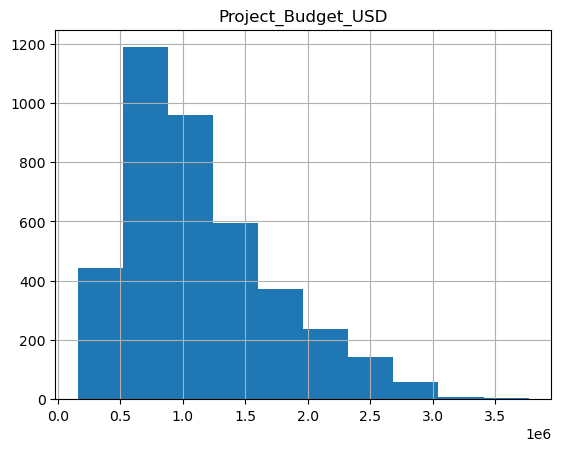

In [103]:
plot_histogram(df, "Project_Budget_USD")

In [104]:
candidate_features = [
    "Project_Budget_USD",
    "Estimated_Timeline_Months",
    "Complexity_Score",
    "Previous_Delivery_Success_Rate",
    "Resource_Availability",
    "Historical_Risk_Incidents",
]

In [105]:
df[candidate_features].describe()

,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Previous_Delivery_Success_Rate,Resource_Availability,Historical_Risk_Incidents
count,4.000000e+03,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,1.143032e+06,17.147750,6.192525,0.750437,0.651695,1.507250
std,5.908781e+05,6.926609,2.212538,0.143712,0.201163,1.210915
min,1.593555e+05,2.000000,1.620000,0.150000,0.300000,0.000000
25%,6.925329e+05,12.000000,4.460000,0.660000,0.480000,1.000000
50%,1.007472e+06,17.000000,6.015000,0.770000,0.650000,1.000000
75%,1.475870e+06,22.000000,7.862500,0.860000,0.820000,2.000000
max,3.768354e+06,36.000000,10.000000,0.990000,1.000000,8.000000


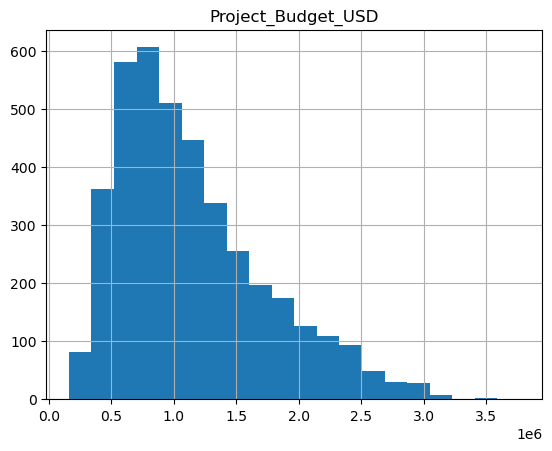

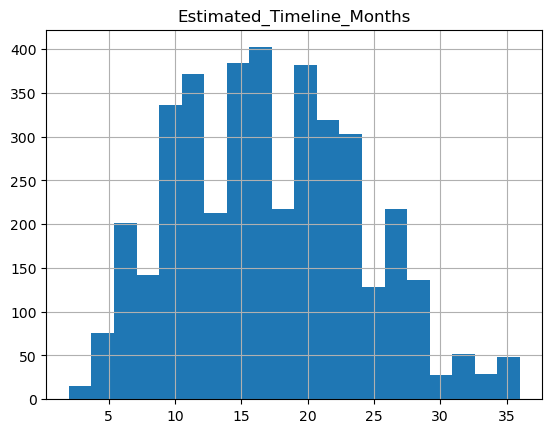

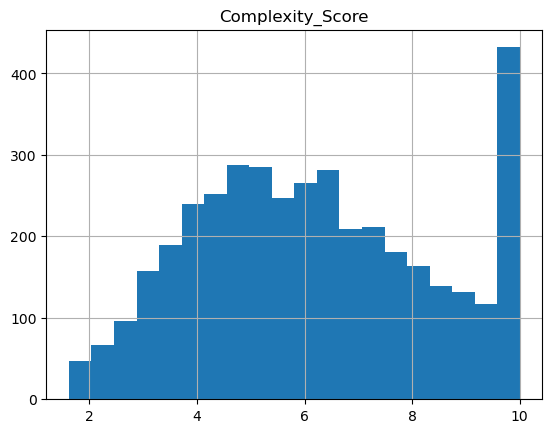

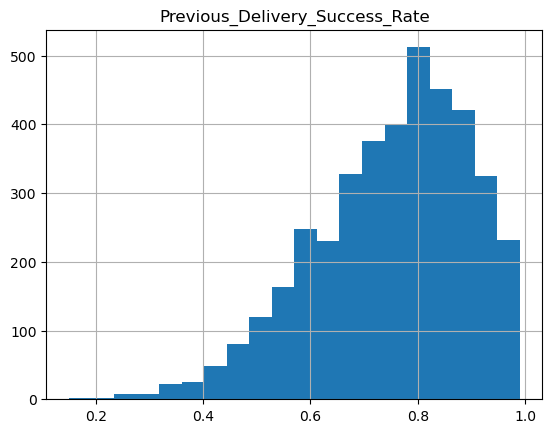

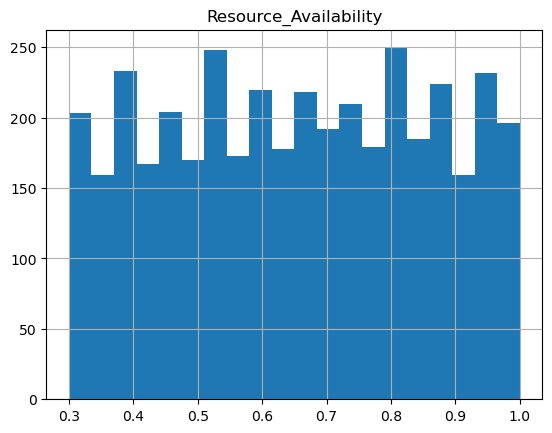

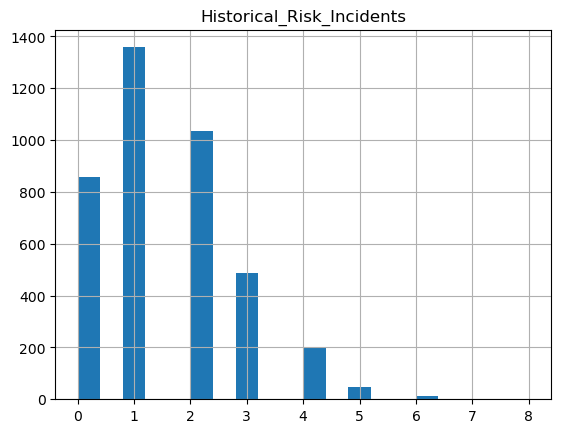

In [106]:
for column in candidate_features:
    df[column].hist(bins=20)
    plt.title(column)
    plt.show()

# 6. Correlations

In [107]:
correlation = df[candidate_features].corr()

correlation

,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Previous_Delivery_Success_Rate,Resource_Availability,Historical_Risk_Incidents
Project_Budget_USD,1.000000,0.863532,0.583238,-0.033817,0.001698,-0.011279
Estimated_Timeline_Months,0.863532,1.000000,0.792578,-0.045353,0.003268,-0.008789
Complexity_Score,0.583238,0.792578,1.000000,-0.038973,-0.004851,-0.012619
Previous_Delivery_Success_Rate,-0.033817,-0.045353,-0.038973,1.000000,0.016040,0.029849
Resource_Availability,0.001698,0.003268,-0.004851,0.016040,1.000000,-0.004475
Historical_Risk_Incidents,-0.011279,-0.008789,-0.012619,0.029849,-0.004475,1.000000


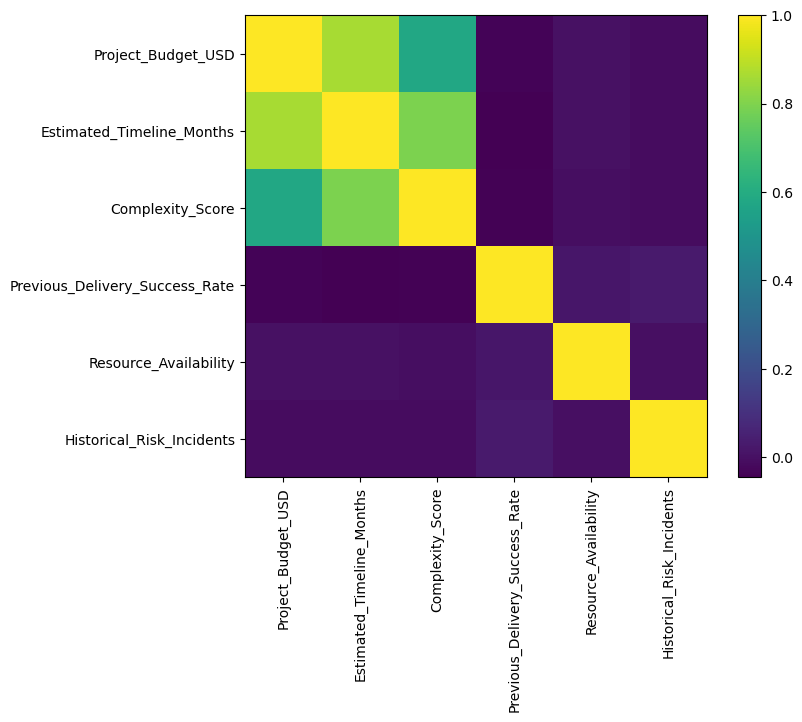

In [108]:
plt.figure(figsize=(8,6))

plt.imshow(correlation)

plt.colorbar()

plt.xticks(range(len(candidate_features)), candidate_features, rotation=90)

plt.yticks(range(len(candidate_features)), candidate_features)

plt.show()

In [109]:
candidate_features = [
    "Project_Budget_USD",
    "Estimated_Timeline_Months",
    "Complexity_Score",
    "Previous_Delivery_Success_Rate",
    "Resource_Availability",
    "Historical_Risk_Incidents"
]

In [110]:
df[candidate_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Project_Budget_USD,4000.0,1.143032e+06,590878.115350,159355.55,692532.915,1007471.805,1.475870e+06,3768354.37
Estimated_Timeline_Months,4000.0,1.714775e+01,6.926609,2.00,12.000,17.000,2.200000e+01,36.00
Complexity_Score,4000.0,6.192525e+00,2.212538,1.62,4.460,6.015,7.862500e+00,10.00
Previous_Delivery_Success_Rate,4000.0,7.504375e-01,0.143712,0.15,0.660,0.770,8.600000e-01,0.99
Resource_Availability,4000.0,6.516950e-01,0.201163,0.30,0.480,0.650,8.200000e-01,1.00
Historical_Risk_Incidents,4000.0,1.507250e+00,1.210915,0.00,1.000,1.000,2.000000e+00,8.00


In [111]:
df[candidate_features].isna().sum()

Project_Budget_USD                0
Estimated_Timeline_Months         0
Complexity_Score                  0
Previous_Delivery_Success_Rate    0
Resource_Availability             0
Historical_Risk_Incidents         0
dtype: int64

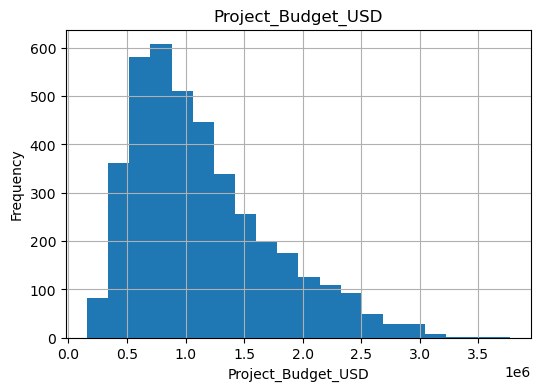

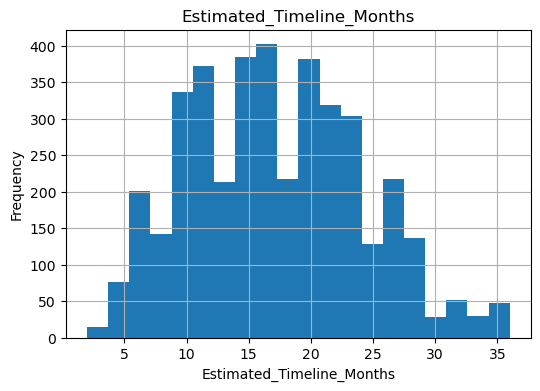

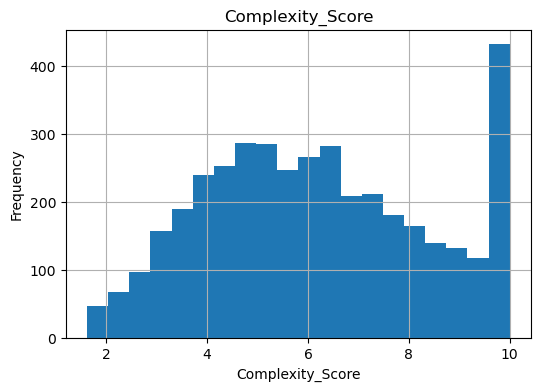

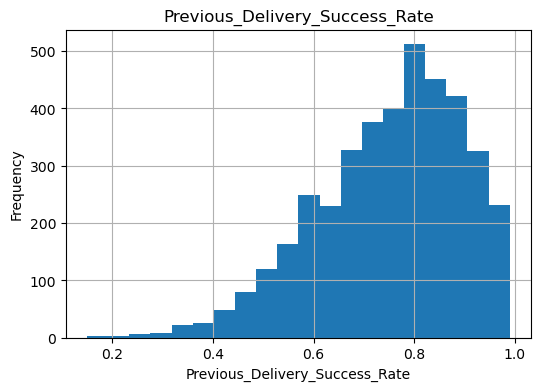

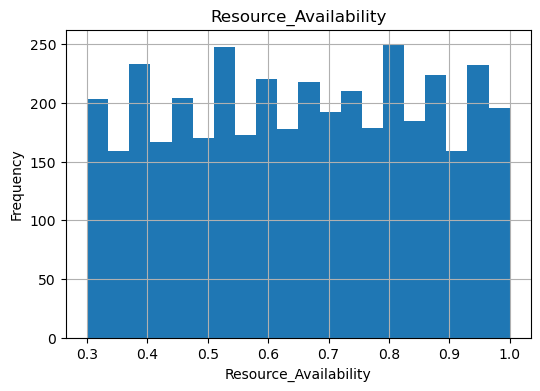

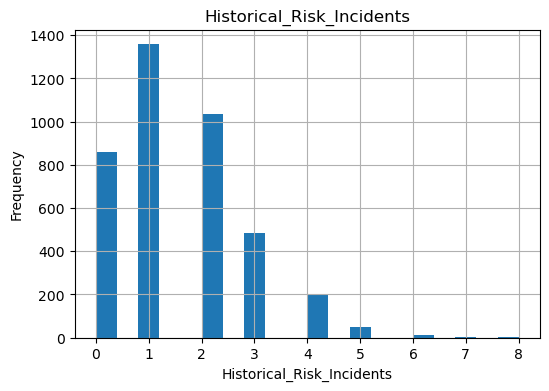

In [112]:
import matplotlib.pyplot as plt

for column in candidate_features:
    plt.figure(figsize=(6,4))

    df[column].hist(bins=20)

    plt.title(column)

    plt.xlabel(column)

    plt.ylabel("Frequency")

    plt.show()

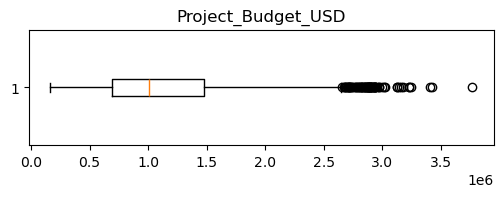

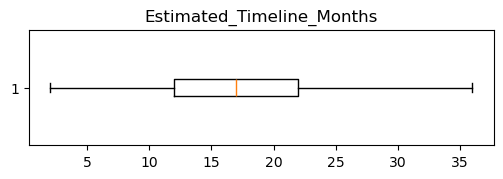

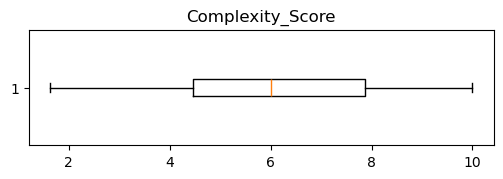

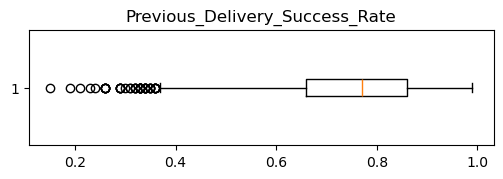

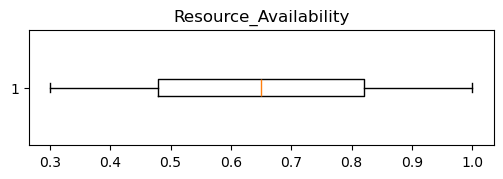

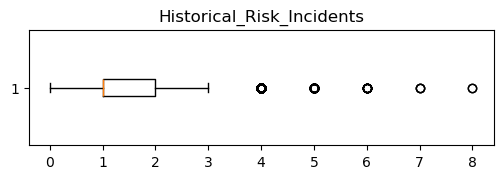

In [113]:
for column in candidate_features:

    plt.figure(figsize=(6,1.5))

    plt.boxplot(df[column], vert=False)

    plt.title(column)

    plt.show()

In [114]:
correlation = df[candidate_features].corr()

correlation

,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Previous_Delivery_Success_Rate,Resource_Availability,Historical_Risk_Incidents
Project_Budget_USD,1.000000,0.863532,0.583238,-0.033817,0.001698,-0.011279
Estimated_Timeline_Months,0.863532,1.000000,0.792578,-0.045353,0.003268,-0.008789
Complexity_Score,0.583238,0.792578,1.000000,-0.038973,-0.004851,-0.012619
Previous_Delivery_Success_Rate,-0.033817,-0.045353,-0.038973,1.000000,0.016040,0.029849
Resource_Availability,0.001698,0.003268,-0.004851,0.016040,1.000000,-0.004475
Historical_Risk_Incidents,-0.011279,-0.008789,-0.012619,0.029849,-0.004475,1.000000


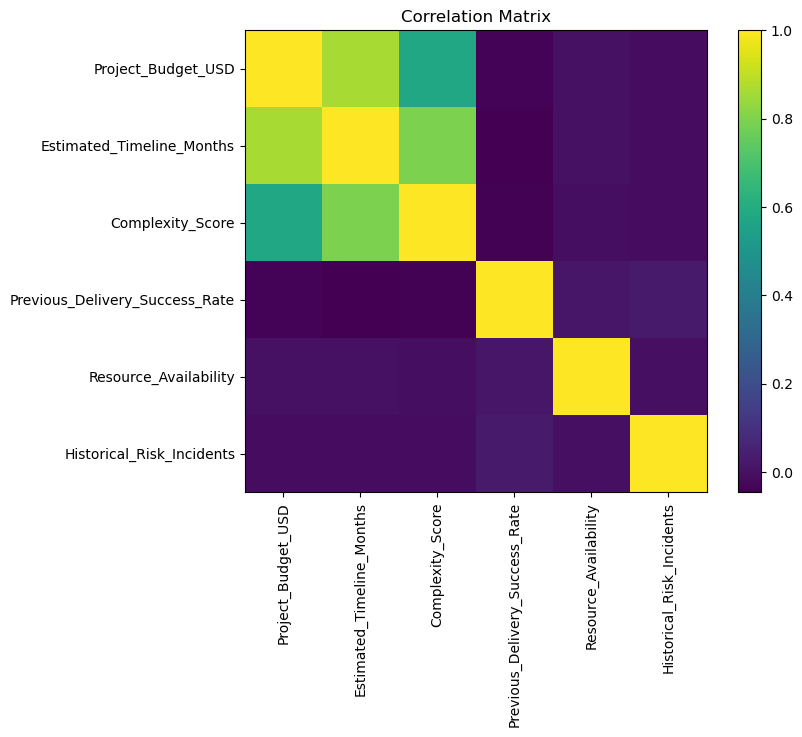

In [115]:
plt.figure(figsize=(8,6))

plt.imshow(correlation)

plt.colorbar()

plt.xticks(
    range(len(candidate_features)),
    candidate_features,
    rotation=90
)

plt.yticks(
    range(len(candidate_features)),
    candidate_features
)

plt.title("Correlation Matrix")

plt.show()

In [116]:
def plot_histogram(df, column, bins=20):
    """
    Plot a histogram for a numeric column.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset.
    column : str
        Column to plot.
    bins : int, default=20
        Number of histogram bins.
    """

    plt.figure(figsize=(6,4))

    plt.hist(df[column], bins=bins)

    plt.title(column)

    plt.xlabel(column)

    plt.ylabel("Frequency")

    plt.show()

# 7. Selection Criteria

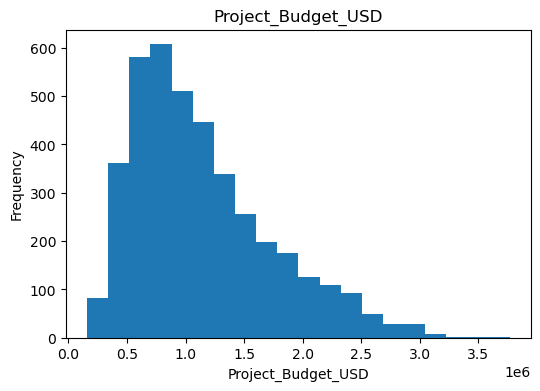

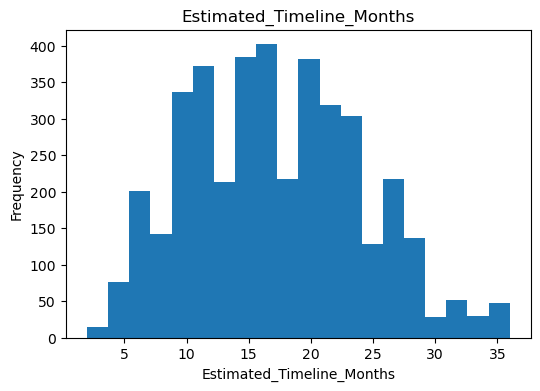

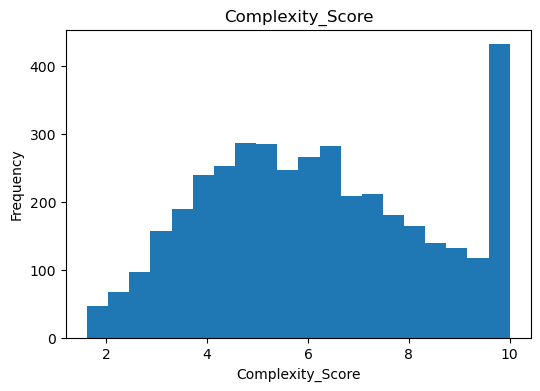

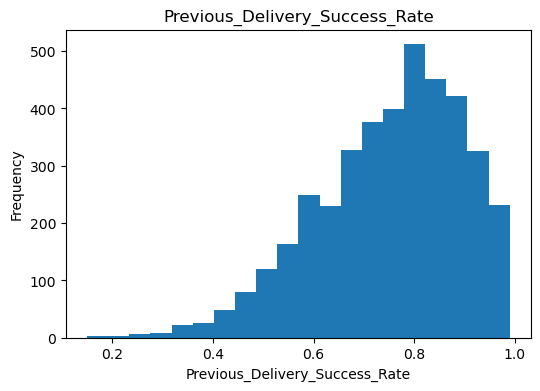

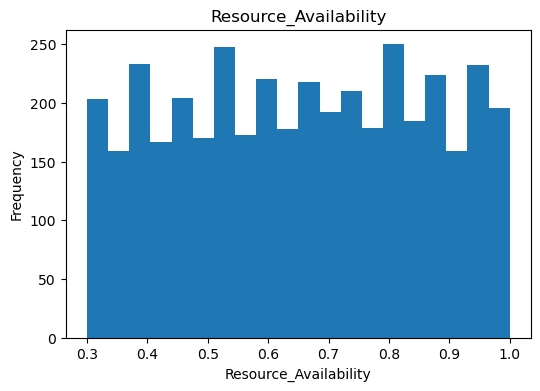

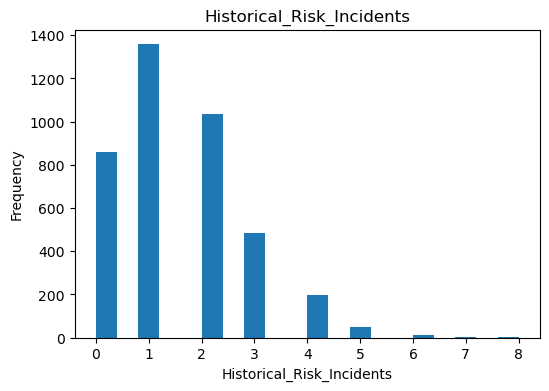

In [117]:
for feature in candidate_features:
    plot_histogram(df, feature)

In [118]:
criteria = {
    "Project_Budget_USD": "min",
    "Estimated_Timeline_Months": "min",
    "Complexity_Score": "min",
    "Previous_Delivery_Success_Rate": "max",
    "Resource_Availability": "max",
    "Historical_Risk_Incidents": "min",
}

In [119]:
criteria["Project_Budget_USD"]

'min'

In [120]:
df[list(criteria.keys())].head()

,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Previous_Delivery_Success_Rate,Resource_Availability,Historical_Risk_Incidents
0,1526276.55,32,9.70,0.80,0.98,2
1,390790.15,9,2.72,0.73,0.95,2
2,246674.76,6,2.04,0.91,0.79,2
3,1427830.63,17,7.54,0.71,0.52,1
4,1696746.64,24,6.68,0.83,0.58,1


In [121]:
print(type(df))
print(df.shape)

print(criteria)

<class 'pandas.core.frame.DataFrame'>
(4000, 51)
{'Project_Budget_USD': 'min', 'Estimated_Timeline_Months': 'min', 'Complexity_Score': 'min', 'Previous_Delivery_Success_Rate': 'max', 'Resource_Availability': 'max', 'Historical_Risk_Incidents': 'min'}
